# Metropolis-Within-Gibbs

In `gibbs.ipynb`, we saw that Gibbs sampling is useful when we can sample directly from each full conditional distribution. In `metropolis_hastings.ipynb`, we saw how to construct a Markov chain when we can evaluate a target distribution but cannot sample from it directly. Metropolis-within-Gibbs combines these two ideas.

For some components of $\theta$, we may be able to make an exact Gibbs draw. For other components, the full conditional distribution may be known only up to proportionality or may not belong to a distribution that is easy to sample from. We can then use a Metropolis Hastings step to update that component.

## The Metropolis-Within-Gibbs Problem

Suppose that the parameter vector can be broken into two blocks, $\theta = (\theta_1, \theta_2)$, with target distribution
$$
\pi(\theta_1, \theta_2 | y).
$$
Assume that we can sample directly from $p(\theta_1 | \theta_2, y)$, but cannot sample directly from $p(\theta_2 | \theta_1, y)$. Starting at $(\theta_1^{t-1}, \theta_2^{t-1})$, one iteration is then:

1. Make the exact Gibbs update
$$
\theta_1^t \sim p(\theta_1 | \theta_2^{t-1}, y).
$$
2. Starting from $\theta_2^{t-1}$, make one Metropolis Hastings update whose target is
$$
p(\theta_2 | \theta_1^t, y).
$$
The accepted or retained value from the second step becomes $\theta_2^t$. Together, $(\theta_1^t, \theta_2^t)$ is one completed iteration of the sampler.

Suppose that we propose $\theta_2^*$ from
$$
q(\theta_2^* | \theta_2^{t-1}, \theta_1^t, y).
$$
The Metropolis Hastings acceptance ratio for this update is
$$
r = \frac{p(\theta_2^* | \theta_1^t, y)q(\theta_2^{t-1} | \theta_2^*, \theta_1^t, y)}{p(\theta_2^{t-1} | \theta_1^t, y)q(\theta_2^* | \theta_2^{t-1}, \theta_1^t, y)},
$$
with acceptance probability
$$
\alpha = \min(1,r).
$$
As before, we will work on the log scale. Any normalizing constant that does not depend on $\theta_2$ cancels from the ratio, so an unnormalized conditional density is sufficient. If the proposal is symmetric, the forward and reverse proposal densities also cancel. We will nevertheless retain both proposal terms in the code so that the Metropolis Hastings step is not restricted to symmetric proposals.

### Why Does Metropolis-Within-Gibbs Preserve the Target?

The first update is an ordinary Gibbs update, so it preserves the joint target distribution. For a fixed value of $\theta_1^t$, the second update is a valid Metropolis Hastings transition with invariant distribution $p(\theta_2 | \theta_1^t, y)$. Therefore, both updates preserve the appropriate target, and their composition preserves $\pi(\theta_1, \theta_2 | y)$.

This does not mean that the chain reaches the target distribution after one iteration. It means that once the chain has the target distribution, an additional iteration leaves that distribution unchanged. Convergence and mixing must still be checked.

## Example Implementation: Bivariate Normal

We will use the same target distribution as in `gibbs.ipynb`. Let
$$
\begin{pmatrix}\theta_1 \\ \theta_2\end{pmatrix}
\sim N\left(
\begin{pmatrix}0 \\ 0\end{pmatrix},
\begin{pmatrix}1 & \rho \\ \rho & 1\end{pmatrix}
\right).
$$
The full conditional distributions are
$$
\theta_1 | \theta_2 \sim N(\rho\theta_2, 1-\rho^2)
$$
and
$$
\theta_2 | \theta_1 \sim N(\rho\theta_1, 1-\rho^2).
$$
To demonstrate Metropolis-within-Gibbs, we will draw $\theta_1$ exactly from its conditional distribution and pretend that we cannot draw $\theta_2$ directly. Instead, we will update $\theta_2$ using a random-walk Metropolis Hastings step. Since we know the exact target distribution in this example, we can check the result against the truth.

In [1]:
from scipy.stats import norm
import matplotlib.pyplot as plt

import numpy as np

### Conditional Distribution Functions

We first write functions for the conditional mean and standard deviation, the conditional log density, and an exact conditional draw. The same conditional log density will later be used as the target of the inner Metropolis Hastings step.

In [2]:
def theta_cond_params(conditioning_value, rho=0.9):
    if not -1 < rho < 1:
        raise ValueError("rho must be strictly between -1 and 1")

    conditional_mean = rho * conditioning_value
    conditional_sd = np.sqrt(1 - rho**2)
    return conditional_mean, conditional_sd


def conditional_logpdf(value, conditioning_value, rho=0.9):
    conditional_mean, conditional_sd = theta_cond_params(conditioning_value, rho)
    return norm.logpdf(value, loc=conditional_mean, scale=conditional_sd)


def sample_conditional(conditioning_value, rng, rho=0.9):
    conditional_mean, conditional_sd = theta_cond_params(conditioning_value, rho)
    return rng.normal(loc=conditional_mean, scale=conditional_sd)

In [3]:
# Testing the conditional distribution functions
test_mean, test_sd = theta_cond_params(conditioning_value=2.0, rho=0.9)
assert np.isclose(test_mean, 1.8)
assert np.isclose(test_sd, np.sqrt(0.19))
assert np.isfinite(conditional_logpdf(1.8, conditioning_value=2.0, rho=0.9))

test_rng = np.random.default_rng(13)
test_draw = sample_conditional(conditioning_value=2.0, rng=test_rng, rho=0.9)
assert np.isscalar(test_draw)
print("TEST PASSED")

TEST PASSED


### Implementing a Single Metropolis Hastings Step

The function below performs only one Metropolis Hastings transition. This is the part that will be placed inside the Gibbs sampling loop. It returns both the next state and an indicator telling us whether the proposal was accepted. Recording this indicator will allow us to calculate the acceptance rate of the inner Metropolis Hastings update.

In [4]:
def random_walk_proposal(current_state, proposal_sd, rng):
    return rng.normal(loc=current_state, scale=proposal_sd)


def random_walk_logpdf(to_state, from_state, proposal_sd):
    return norm.logpdf(to_state, loc=from_state, scale=proposal_sd)

In [5]:
def metropolis_hastings_step(
    log_target,
    current_state,
    proposal_sampler,
    proposal_logpdf,
    proposal_sd,
    rng,
):
    # Catching exceptions
    if proposal_sd <= 0:
        raise ValueError("proposal_sd must be positive")

    # Propose a new state
    proposed_state = proposal_sampler(current_state, proposal_sd, rng)

    # Acceptance probability
    log_target_current = log_target(current_state)
    log_target_proposed = log_target(proposed_state)
    log_q_forward = proposal_logpdf(proposed_state, current_state, proposal_sd)
    log_q_reverse = proposal_logpdf(current_state, proposed_state, proposal_sd)

    log_r = (
        log_target_proposed
        + log_q_reverse
        - log_target_current
        - log_q_forward
    )
    log_a = min(0.0, log_r)

    # Decision
    if np.log(rng.uniform()) < log_a:
        return proposed_state, True

    return current_state, False

In [6]:
# Testing the proposal and one-step function
assert np.isclose(
    random_walk_logpdf(1.0, -1.0, proposal_sd=0.5),
    random_walk_logpdf(-1.0, 1.0, proposal_sd=0.5),
)

test_rng = np.random.default_rng(13)
test_log_target = lambda value: norm.logpdf(value)
test_state, test_accepted = metropolis_hastings_step(
    log_target=test_log_target,
    current_state=0.0,
    proposal_sampler=random_walk_proposal,
    proposal_logpdf=random_walk_logpdf,
    proposal_sd=1.0,
    rng=test_rng,
)
assert np.isscalar(test_state)
assert isinstance(test_accepted, (bool, np.bool_))
print("TEST PASSED")

TEST PASSED


### Implementing the Metropolis-Within-Gibbs Sampler

At each iteration, we first update $\theta_1$ exactly using the current value of $\theta_2$. We then hold the new $\theta_1$ fixed and use `metropolis_hastings_step()` to update $\theta_2$. Notice that the conditional target passed to the inner step changes as $\theta_1$ changes.

In [7]:
def metropolis_within_gibbs(
    initial_state,
    n_iterations,
    rho,
    proposal_sd,
    rng,
):
    # Catching exceptions
    initial_state = np.asarray(initial_state, dtype=float)
    if initial_state.shape != (2,):
        raise ValueError("initial_state must contain theta_1 and theta_2")
    if n_iterations < 2:
        raise ValueError("n_iterations must be at least 2")
    if proposal_sd <= 0:
        raise ValueError("proposal_sd must be positive")
    theta_cond_params(0.0, rho)

    # Initial parameters
    theta_1_current, theta_2_current = initial_state
    samples = np.zeros((n_iterations, 2))
    accepted = np.zeros(n_iterations, dtype=bool)
    samples[0] = initial_state

    # Sampling loop
    for t in range(1, n_iterations):
        # Exact Gibbs update for theta_1
        theta_1_current = sample_conditional(
            conditioning_value=theta_2_current,
            rng=rng,
            rho=rho,
        )

        # Metropolis Hastings update for theta_2
        def log_theta_2_conditional(theta_2_candidate):
            return conditional_logpdf(
                value=theta_2_candidate,
                conditioning_value=theta_1_current,
                rho=rho,
            )

        theta_2_current, accepted[t] = metropolis_hastings_step(
            log_target=log_theta_2_conditional,
            current_state=theta_2_current,
            proposal_sampler=random_walk_proposal,
            proposal_logpdf=random_walk_logpdf,
            proposal_sd=proposal_sd,
            rng=rng,
        )

        # Store sample
        samples[t] = (theta_1_current, theta_2_current)

    return samples, accepted

In [8]:
# Testing the Metropolis-within-Gibbs sampler
test_samples, test_accepted = metropolis_within_gibbs(
    initial_state=(-4.0, 4.0),
    n_iterations=100,
    rho=0.9,
    proposal_sd=1.0,
    rng=np.random.default_rng(13),
)
assert test_samples.shape == (100, 2)
assert test_accepted.shape == (100,)
assert np.all(np.isfinite(test_samples))
print("TEST PASSED")

TEST PASSED


### Running the Simulation

We will run three chains from dispersed initial states. The target correlation is set to $\rho=0.9$, and the random-walk proposal standard deviation is set to 1.0.

In [9]:
rho = 0.9
proposal_sd = 1.0
n_iterations = 10_000
burn_in = 1_000
initial_states = [(-4.0, 4.0), (0.0, 0.0), (4.0, -4.0)]
chain_seeds = [13, 14, 15]

chains = []
acceptance_indicators = []

for initial_state, seed in zip(initial_states, chain_seeds):
    chain, accepted = metropolis_within_gibbs(
        initial_state=initial_state,
        n_iterations=n_iterations,
        rho=rho,
        proposal_sd=proposal_sd,
        rng=np.random.default_rng(seed),
    )
    chains.append(chain)
    acceptance_indicators.append(accepted)

chains = np.asarray(chains)
acceptance_indicators = np.asarray(acceptance_indicators)
post_burn_chains = chains[:, burn_in:, :]
pooled_samples = post_burn_chains.reshape(-1, 2)

#### Trace Plots

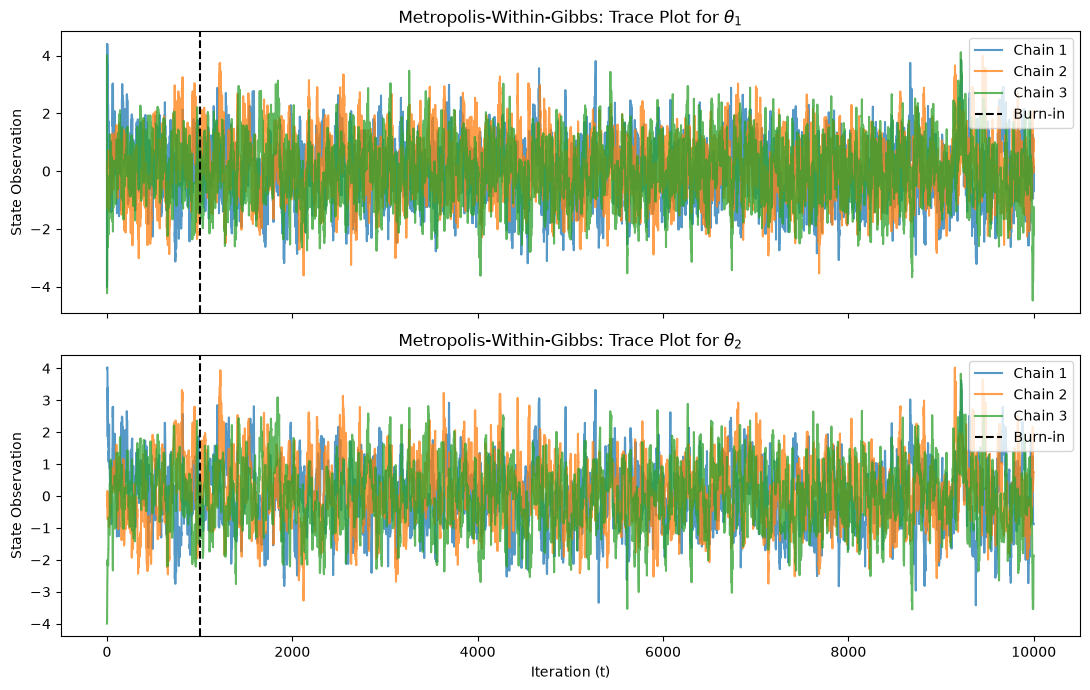

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for chain_index, chain in enumerate(chains, start=1):
    axes[0].plot(chain[:, 0], alpha=0.75, label=f"Chain {chain_index}")
    axes[1].plot(chain[:, 1], alpha=0.75, label=f"Chain {chain_index}")

axes[0].axvline(burn_in, color="black", linestyle="--", label="Burn-in")
axes[1].axvline(burn_in, color="black", linestyle="--", label="Burn-in")
axes[0].set_title(r"Metropolis-Within-Gibbs: Trace Plot for $\theta_1$")
axes[1].set_title(r"Metropolis-Within-Gibbs: Trace Plot for $\theta_2$")
axes[0].set_ylabel("State Observation")
axes[1].set_ylabel("State Observation")
axes[1].set_xlabel("Iteration (t)")
axes[0].legend(loc="upper right")
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

The chains move from their different initial states toward the same region and continue to explore it. We should also expect visible autocorrelation because each new draw depends on the previous state. In addition, rejected proposals cause consecutive values of $\theta_2$ to be equal. A trace plot is useful, but it is not sufficient on its own, so we will also examine the sampled distribution and autocorrelation.

#### Joint and Marginal Distributions

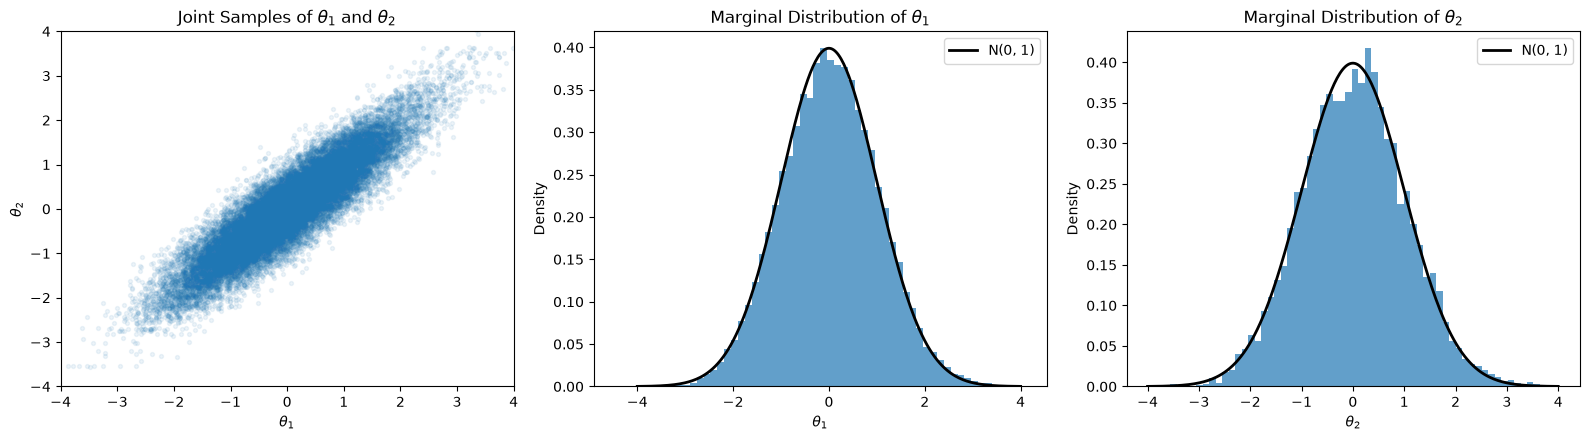

In [11]:
grid = np.linspace(-4, 4, 300)
target_marginal = norm.pdf(grid, loc=0.0, scale=1.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(
    pooled_samples[:, 0],
    pooled_samples[:, 1],
    alpha=0.08,
    s=8,
)
axes[0].set_title(r"Joint Samples of $\theta_1$ and $\theta_2$")
axes[0].set_xlabel(r"$\theta_1$")
axes[0].set_ylabel(r"$\theta_2$")
axes[0].set_xlim(-4, 4)
axes[0].set_ylim(-4, 4)

axes[1].hist(pooled_samples[:, 0], bins=60, density=True, alpha=0.7)
axes[1].plot(grid, target_marginal, color="black", linewidth=2, label="N(0, 1)")
axes[1].set_title(r"Marginal Distribution of $\theta_1$")
axes[1].set_xlabel(r"$\theta_1$")
axes[1].set_ylabel("Density")
axes[1].legend()

axes[2].hist(pooled_samples[:, 1], bins=60, density=True, alpha=0.7)
axes[2].plot(grid, target_marginal, color="black", linewidth=2, label="N(0, 1)")
axes[2].set_title(r"Marginal Distribution of $\theta_2$")
axes[2].set_xlabel(r"$\theta_2$")
axes[2].set_ylabel("Density")
axes[2].legend()

plt.tight_layout()
plt.show()

In [12]:
empirical_mean = pooled_samples.mean(axis=0)
empirical_variance = pooled_samples.var(axis=0)
empirical_correlation = np.corrcoef(pooled_samples.T)[0, 1]
acceptance_rates = acceptance_indicators[:, 1:].mean(axis=1)

print(f"Empirical means: {empirical_mean}")
print("Target means:    [0. 0.]")
print()
print(f"Empirical variances: {empirical_variance}")
print("Target variances:    [1. 1.]")
print()
print(f"Empirical correlation: {empirical_correlation:.3f}")
print(f"Target correlation:    {rho:.3f}")
print()
for chain_index, acceptance_rate in enumerate(acceptance_rates, start=1):
    print(f"Chain {chain_index} acceptance rate: {acceptance_rate:.3f}")

Empirical means: [0.02798795 0.02745561]
Target means:    [0. 0.]

Empirical variances: [1.03191699 1.03146249]
Target variances:    [1. 1.]

Empirical correlation: 0.903
Target correlation:    0.900

Chain 1 acceptance rate: 0.455
Chain 2 acceptance rate: 0.455
Chain 3 acceptance rate: 0.452


The marginal distributions should be close to $N(0,1)$, while the joint samples should show the strong positive relationship caused by $\rho=0.9$. The acceptance rate is a diagnostic of the inner Metropolis Hastings update only. It does not tell us by itself whether the whole chain is mixing well.

#### Autocorrelation

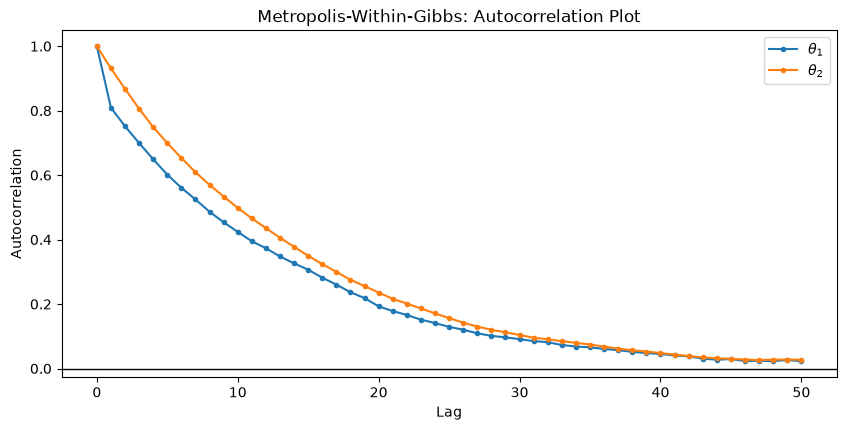

In [13]:
def sample_acf(samples, max_lag):
    samples = np.asarray(samples, dtype=float)
    centered_samples = samples - samples.mean()
    denominator = np.dot(centered_samples, centered_samples)

    if denominator == 0:
        raise ValueError("samples must have non-zero variance")

    autocorrelations = np.empty(max_lag + 1)
    autocorrelations[0] = 1.0

    for lag in range(1, max_lag + 1):
        autocorrelations[lag] = (
            np.dot(centered_samples[:-lag], centered_samples[lag:])
            / denominator
        )

    return autocorrelations


max_lag = 50
acf_theta_1 = sample_acf(post_burn_chains[0, :, 0], max_lag=max_lag)
acf_theta_2 = sample_acf(post_burn_chains[0, :, 1], max_lag=max_lag)

plt.figure(figsize=(10, 4.5))
plt.plot(acf_theta_1, marker="o", markersize=3, label=r"$\theta_1$")
plt.plot(acf_theta_2, marker="o", markersize=3, label=r"$\theta_2$")
plt.axhline(0.0, color="black", linewidth=1)
plt.title("Metropolis-Within-Gibbs: Autocorrelation Plot")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.legend()
plt.show()

Even though $\theta_1$ is drawn exactly from its full conditional at every iteration, successive values of $\theta_1$ are not independent. Dependence is passed through $\theta_2$, and the Metropolis Hastings rejections can add further persistence to the chain. This is why an exact Gibbs draw for one block does not remove the need to inspect the chain as a whole.

### Proposal Standard Deviation Experiment

The proposal standard deviation controls how far the inner Metropolis Hastings step tries to move. We will compare several values using the same target distribution. For each value, we will calculate the acceptance rate and the lag-one autocorrelation of $\theta_2$.

In [14]:
proposal_sds = [0.05, 0.25, 0.5, 1.0, 3.0]
experiment_results = []

for experiment_index, experiment_sd in enumerate(proposal_sds):
    experiment_chain, experiment_accepted = metropolis_within_gibbs(
        initial_state=(0.0, 0.0),
        n_iterations=8_000,
        rho=rho,
        proposal_sd=experiment_sd,
        rng=np.random.default_rng(100 + experiment_index),
    )
    experiment_post_burn = experiment_chain[burn_in:]
    lag_one_theta_2 = sample_acf(
        experiment_post_burn[:, 1],
        max_lag=1,
    )[1]
    experiment_results.append(
        (
            experiment_sd,
            experiment_accepted[1:].mean(),
            lag_one_theta_2,
            experiment_post_burn[:, 1].var(),
        )
    )

print("Proposal SD | Acceptance Rate | Lag-1 ACF(theta_2) | Variance(theta_2)")
for experiment_sd, acceptance_rate, lag_one, variance in experiment_results:
    print(
        f"{experiment_sd:11.2f} | "
        f"{acceptance_rate:15.3f} | "
        f"{lag_one:18.3f} | "
        f"{variance:17.3f}"
    )

Proposal SD | Acceptance Rate | Lag-1 ACF(theta_2) | Variance(theta_2)
       0.05 |           0.964 |              0.998 |             0.534
       0.25 |           0.820 |              0.975 |             0.839
       0.50 |           0.668 |              0.952 |             1.002
       1.00 |           0.451 |              0.937 |             1.084
       3.00 |           0.183 |              0.954 |             0.907


A very small proposal standard deviation should produce a high acceptance rate, but each accepted move is small. A very large proposal standard deviation should propose larger moves, but many of them will be rejected. A useful proposal balances these two behaviours. Therefore, maximizing the acceptance rate is not the objective; we want the chain to explore the target efficiently. Notice that poor exploration can also make a finite-chain variance look far from 1. Changing the proposal scale affects efficiency, but it does not change the stationary target distribution.

### Comparing with the Exact Gibbs Sampler

For this example, we actually can sample $\theta_2$ directly from its conditional distribution. We can therefore compare Metropolis-within-Gibbs with the exact Gibbs sampler. Both samplers have the same target distribution, but their transition mechanisms are different.

In [15]:
def gibbs_bivariate_normal(initial_state, n_iterations, rho, rng):
    initial_state = np.asarray(initial_state, dtype=float)
    if initial_state.shape != (2,):
        raise ValueError("initial_state must contain theta_1 and theta_2")
    if n_iterations < 2:
        raise ValueError("n_iterations must be at least 2")
    theta_cond_params(0.0, rho)

    theta_1_current, theta_2_current = initial_state
    samples = np.zeros((n_iterations, 2))
    samples[0] = initial_state

    for t in range(1, n_iterations):
        theta_1_current = sample_conditional(theta_2_current, rng, rho)
        theta_2_current = sample_conditional(theta_1_current, rng, rho)
        samples[t] = (theta_1_current, theta_2_current)

    return samples


exact_gibbs_chain = gibbs_bivariate_normal(
    initial_state=(-4.0, 4.0),
    n_iterations=n_iterations,
    rho=rho,
    rng=np.random.default_rng(13),
)
exact_gibbs_post_burn = exact_gibbs_chain[burn_in:]
mwg_post_burn = post_burn_chains[0]

exact_gibbs_lag_one = sample_acf(exact_gibbs_post_burn[:, 1], max_lag=1)[1]
mwg_lag_one = sample_acf(mwg_post_burn[:, 1], max_lag=1)[1]

print(f"Exact Gibbs lag-1 ACF for theta_2: {exact_gibbs_lag_one:.3f}")
print(f"Metropolis-within-Gibbs lag-1 ACF for theta_2: {mwg_lag_one:.3f}")
print()
print("Exact Gibbs empirical means:", exact_gibbs_post_burn.mean(axis=0))
print("MWG empirical means:        ", mwg_post_burn.mean(axis=0))
print()
print("Exact Gibbs empirical variances:", exact_gibbs_post_burn.var(axis=0))
print("MWG empirical variances:        ", mwg_post_burn.var(axis=0))

Exact Gibbs lag-1 ACF for theta_2: 0.809
Metropolis-within-Gibbs lag-1 ACF for theta_2: 0.931

Exact Gibbs empirical means: [0.00971038 0.00708163]
MWG empirical means:         [-0.03369015 -0.03593063]

Exact Gibbs empirical variances: [1.0062766  1.01221808]
MWG empirical variances:         [0.99334527 0.99307295]


The exact Gibbs sampler always replaces $\theta_2$ with a new conditional draw, whereas Metropolis-within-Gibbs may retain its current value. Therefore, when exact conditional sampling is available and inexpensive, it is simpler and often preferable in this setting. Metropolis-within-Gibbs becomes useful when an exact conditional draw is unavailable but its density can still be evaluated.

Neither method produces independent samples here. The strong target correlation creates dependence across iterations even for the exact Gibbs sampler.

## Metropolis-Within-Gibbs General Code

We now place the same logic into a more general two-block function. The user supplies an exact sampler for the first conditional, a log density for the second conditional, and a proposal distribution for the second block. The proposal functions are also allowed to depend on the current value of the first block. This form is still limited to two scalar blocks, but it makes the separate roles of the Gibbs and Metropolis Hastings updates explicit.

In [16]:
def metropolis_within_gibbs_general(
    sample_block_1,
    log_block_2_conditional,
    proposal_sampler,
    proposal_logpdf,
    initial_state,
    n_iterations,
    rng,
):
    initial_state = np.asarray(initial_state, dtype=float)
    if initial_state.shape != (2,):
        raise ValueError("initial_state must contain two scalar blocks")
    if n_iterations < 2:
        raise ValueError("n_iterations must be at least 2")

    block_1_current, block_2_current = initial_state
    samples = np.zeros((n_iterations, 2))
    accepted = np.zeros(n_iterations, dtype=bool)
    samples[0] = initial_state

    for t in range(1, n_iterations):
        block_1_current = sample_block_1(block_2_current, rng)
        block_2_proposed = proposal_sampler(
            block_2_current,
            block_1_current,
            rng,
        )

        log_r = (
            log_block_2_conditional(block_2_proposed, block_1_current)
            + proposal_logpdf(
                block_2_current,
                block_2_proposed,
                block_1_current,
            )
            - log_block_2_conditional(block_2_current, block_1_current)
            - proposal_logpdf(
                block_2_proposed,
                block_2_current,
                block_1_current,
            )
        )

        if np.log(rng.uniform()) < min(0.0, log_r):
            block_2_current = block_2_proposed
            accepted[t] = True

        samples[t] = (block_1_current, block_2_current)

    return samples, accepted

In [17]:
# Supplying the bivariate normal components to the general function
general_rho = 0.9
general_proposal_sd = 1.0

sample_block_1 = lambda block_2, rng: sample_conditional(
    conditioning_value=block_2,
    rng=rng,
    rho=general_rho,
)
log_block_2 = lambda block_2, block_1: conditional_logpdf(
    value=block_2,
    conditioning_value=block_1,
    rho=general_rho,
)
proposal_block_2 = lambda current, block_1, rng: random_walk_proposal(
    current_state=current,
    proposal_sd=general_proposal_sd,
    rng=rng,
)
proposal_block_2_logpdf = lambda to_state, from_state, block_1: (
    random_walk_logpdf(
        to_state=to_state,
        from_state=from_state,
        proposal_sd=general_proposal_sd,
    )
)

general_samples, general_accepted = metropolis_within_gibbs_general(
    sample_block_1=sample_block_1,
    log_block_2_conditional=log_block_2,
    proposal_sampler=proposal_block_2,
    proposal_logpdf=proposal_block_2_logpdf,
    initial_state=(-4.0, 4.0),
    n_iterations=1_000,
    rng=np.random.default_rng(13),
)

assert general_samples.shape == (1_000, 2)
assert general_accepted.shape == (1_000,)
print("TEST PASSED")

TEST PASSED


## Main Takeaways

Metropolis-within-Gibbs allows us to combine exact conditional draws with Metropolis Hastings updates. One Metropolis Hastings transition per Gibbs iteration is sufficient for validity; the inner chain does not need to be run until it converges. However, validity does not guarantee efficient exploration. The proposal distribution and its scale affect the acceptance rate, autocorrelation, and overall mixing of the sampler.

This sampler is an important bridge between the basic Gibbs and Metropolis Hastings algorithms and more involved algorithms with latent variables or conditionals that cannot be sampled from directly.